In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

Читаем данные и показываем первые 5 строк.

In [2]:
train_df = pd.read_csv("train.csv")

train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Смотрим структуру данных

In [3]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


Это даёт средние значения, разброс, минимумы и максимумы числовых признаков.

In [4]:
train_df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
train_df = train_df.drop("Cabin", axis=1)

#### Взаимосвязь факта выживания пассажиров и их пола.

Используется график countplot, который показывает количество объектов в каждой категории.
Параметр hue='Survived' разделяет пассажиров на две группы:

0 — не выжил

1 — выжил

График позволяет сравнить количество выживших и погибших среди мужчин и женщин.

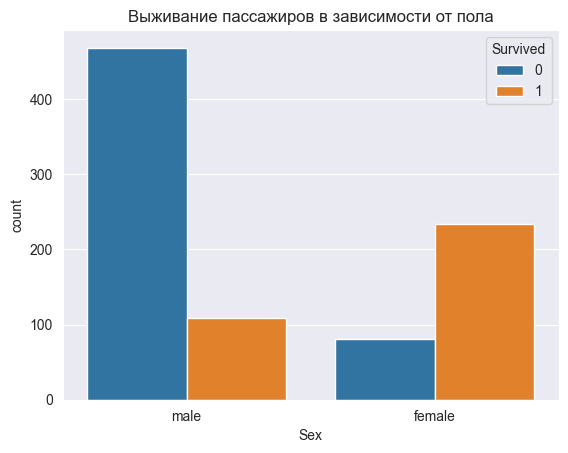

In [6]:
sns.countplot(x="Sex", hue="Survived", data=train_df)

plt.title("Выживание пассажиров в зависимости от пола")
plt.show()

#### Влияние класса каюты на вероятность выживания пассажиров.

Признак Pclass обозначает класс билета:

1 — первый класс

2 — второй класс

3 — третий класс

Используется график countplot, который показывает количество выживших и погибших пассажиров в каждом классе.

График позволяет выявить связь между классом каюты и выживаемостью пассажиров.

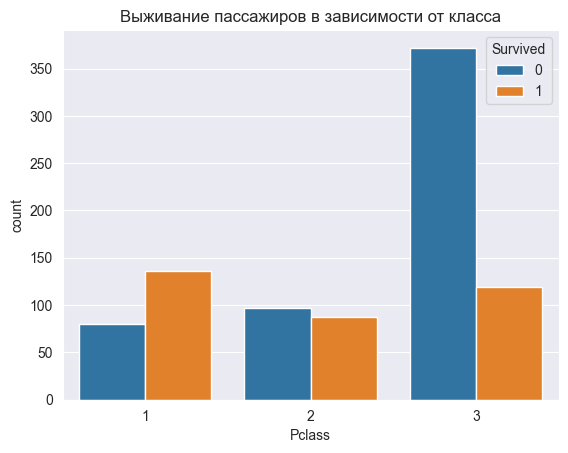

In [7]:
sns.countplot(x="Pclass", hue="Survived", data=train_df)

plt.title("Выживание пассажиров в зависимости от класса")
plt.show()

#### Связь между стоимостью билета (Fare) и классом каюты (Pclass).

Для визуализации используется график boxplot.
Этот тип графика показывает:

медиану распределения

разброс значений

возможные выбросы

График позволяет сравнить распределение стоимости билетов для разных классов.

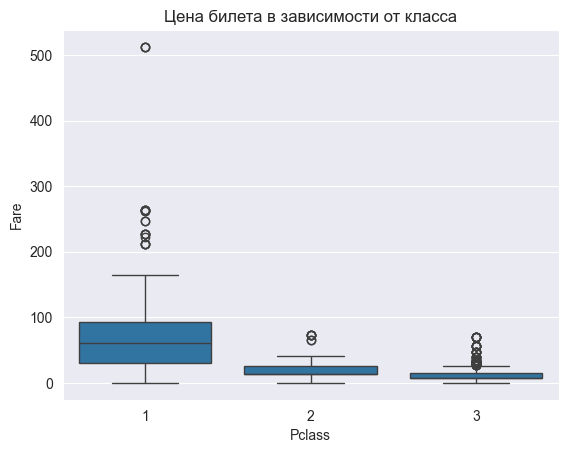

In [12]:
sns.boxplot(x="Pclass", y="Fare", data=train_df)

plt.title("Цена билета в зависимости от класса")
plt.show()

#### Анализ взаимосвязей между числовыми признаками датасета.

Для этого вычисляется матрица корреляций.
Коэффициент корреляции принимает значения от -1 до 1:

1 — сильная положительная связь

-1 — сильная отрицательная связь

0 — связь отсутствует

Матрица отображается с помощью heatmap.
Тепловая карта позволяет наглядно увидеть силу взаимосвязей между признаками.

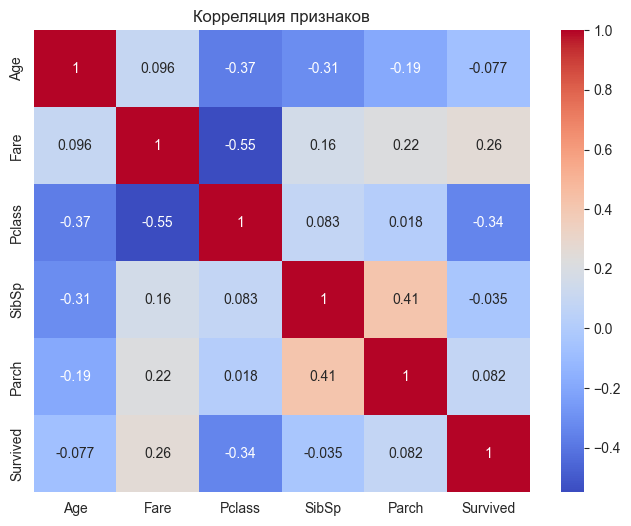

In [13]:
numeric_cols = ["Age", "Fare", "Pclass", "SibSp", "Parch", "Survived"]

corr = train_df[numeric_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Корреляция признаков")
plt.show()